# Data Visualization with Matplotlib & Seaborn
## Titanic Dataset Visualizations

This notebook creates four data visualizations to explore the Titanic dataset.

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better looking plots
sns.set_style("whitegrid")

# Load the Titanic dataset
df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')

print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")

Dataset loaded successfully!
Shape: (891, 12)


---
## Visualization 1 — Bar Chart: Survival Count

**Question:** How many passengers survived vs did not survive?

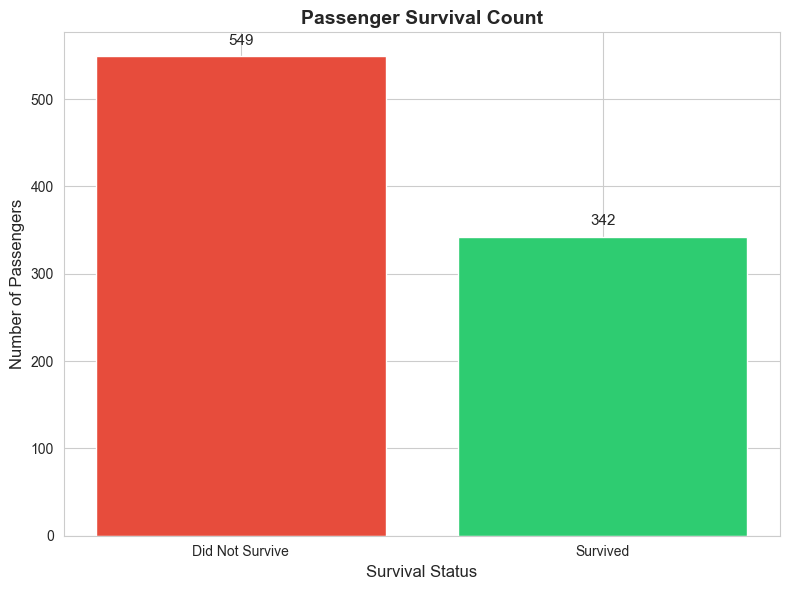


Did Not Survive: 549
Survived: 342


In [2]:
# Calculate survival counts
survival_counts = df['Survived'].value_counts().sort_index()

# Create the bar chart
plt.figure(figsize=(8, 6))
bars = plt.bar(['Did Not Survive', 'Survived'], 
               [survival_counts[0], survival_counts[1]], 
               color=['#E74C3C', '#2ECC71'])

# Add labels and title
plt.xlabel('Survival Status', fontsize=12)
plt.ylabel('Number of Passengers', fontsize=12)
plt.title('Passenger Survival Count', fontsize=14, fontweight='bold')

# Add count labels on top of bars
for bar, count in zip(bars, [survival_counts[0], survival_counts[1]]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, 
             str(count), ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.savefig('visualization1_survival_count.png', bbox_inches='tight', dpi=150)
plt.show()

print(f"\nDid Not Survive: {survival_counts[0]}")
print(f"Survived: {survival_counts[1]}")

**Interpretation:**

This bar chart reveals that significantly more passengers did not survive (549) compared to those who survived (342). The survival rate was approximately 38%, meaning nearly two-thirds of passengers perished in the disaster. This stark difference highlights the tragic nature of the Titanic tragedy.

---
## Visualization 2 — Histogram: Age Distribution

**Question:** What was the age distribution of passengers on board?

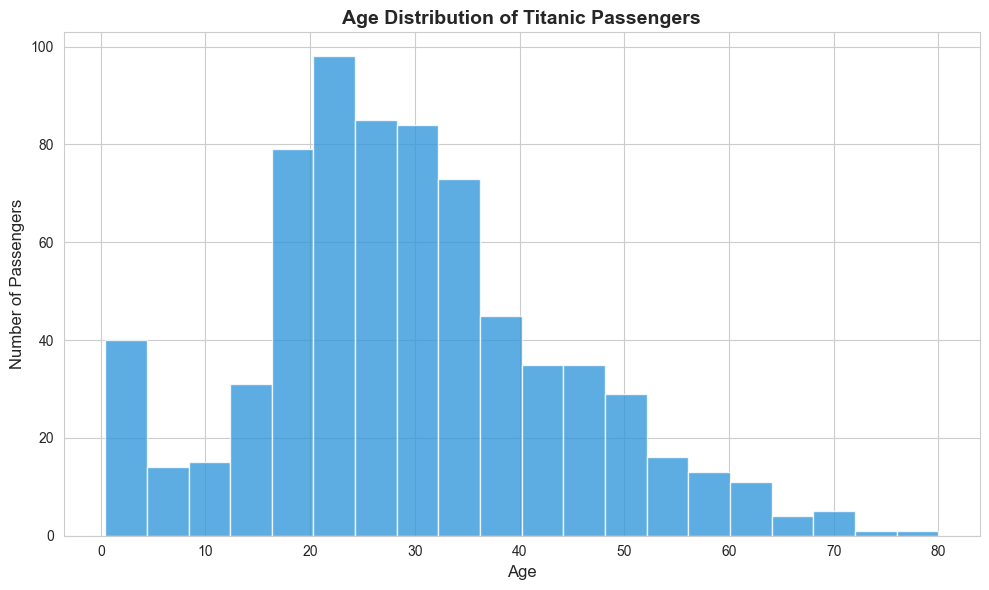


Age Statistics:
Mean Age: 29.7 years
Median Age: 28.0 years
Age Range: 0 - 80 years


In [3]:
# Create the histogram
plt.figure(figsize=(10, 6))
plt.hist(df['Age'].dropna(), bins=20, color='#3498DB', edgecolor='white', alpha=0.8)

# Add labels and title
plt.xlabel('Age', fontsize=12)
plt.ylabel('Number of Passengers', fontsize=12)
plt.title('Age Distribution of Titanic Passengers', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('visualization2_age_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

print(f"\nAge Statistics:")
print(f"Mean Age: {df['Age'].mean():.1f} years")
print(f"Median Age: {df['Age'].median():.1f} years")
print(f"Age Range: {df['Age'].min():.0f} - {df['Age'].max():.0f} years")

**Interpretation:**

The histogram shows that the age distribution of Titanic passengers was right-skewed, with most passengers being between 20-35 years old. There were relatively few elderly passengers (over 60) and a notable number of children under 10. The peak around ages 20-30 suggests the ship carried many young adults, likely traveling for work or emigration opportunities.

---
## Visualization 3 — Grouped Bar Chart: Survival by Class

**Question:** Did survival rates differ by passenger class?

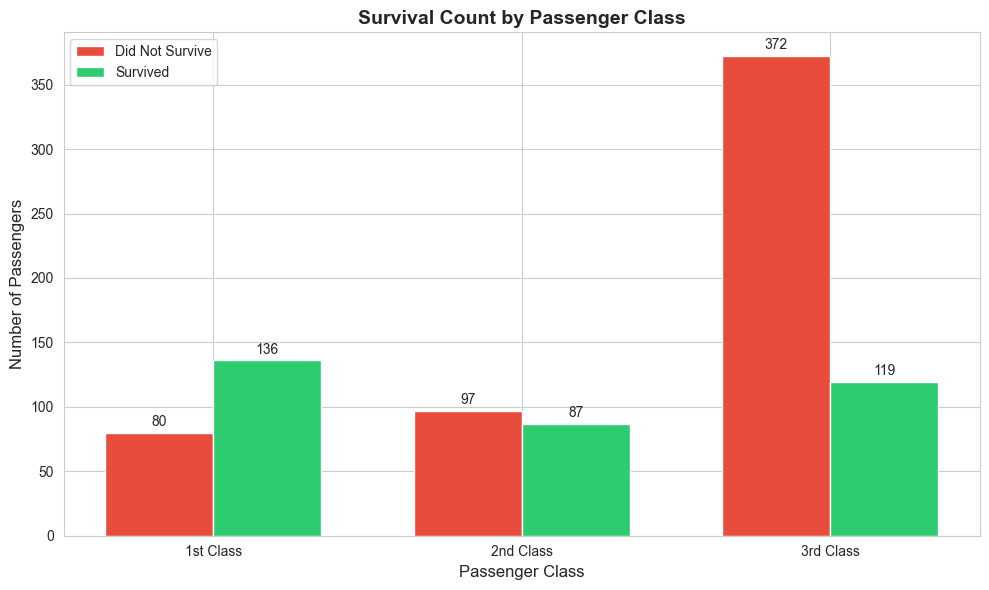


Survival Rates by Class:
  Class 1: 63.0%
  Class 2: 47.3%
  Class 3: 24.2%


In [4]:
# Calculate survival counts by class
survival_by_class = df.groupby(['Pclass', 'Survived']).size().unstack(fill_value=0)

# Set up the grouped bar chart
x = np.arange(3)  # 3 classes
width = 0.35

plt.figure(figsize=(10, 6))
bars1 = plt.bar(x - width/2, survival_by_class[0], width, label='Did Not Survive', color='#E74C3C')
bars2 = plt.bar(x + width/2, survival_by_class[1], width, label='Survived', color='#2ECC71')

# Add labels and title
plt.xlabel('Passenger Class', fontsize=12)
plt.ylabel('Number of Passengers', fontsize=12)
plt.title('Survival Count by Passenger Class', fontsize=14, fontweight='bold')
plt.xticks(x, ['1st Class', '2nd Class', '3rd Class'])
plt.legend()

# Add count labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 3, 
                 str(int(height)), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('visualization3_survival_by_class.png', bbox_inches='tight', dpi=150)
plt.show()

# Print survival rates by class
print("\nSurvival Rates by Class:")
for pclass in [1, 2, 3]:
    class_data = df[df['Pclass'] == pclass]
    rate = class_data['Survived'].mean() * 100
    print(f"  Class {pclass}: {rate:.1f}%")

**Interpretation:**

This grouped bar chart clearly demonstrates that passenger class significantly impacted survival chances. First-class passengers had the highest survival rate (63%), followed by second class (47%), while third-class passengers had the lowest rate (24%). This disparity reflects the historical "women and children first" policy combined with first-class passengers' proximity to lifeboats and priority boarding. The 3rd class had the most deaths both in absolute numbers and proportionally.

---
## Visualization 4 — Scatter Plot: Age vs Fare

**Question:** Is there a relationship between a passenger's age and the fare they paid?

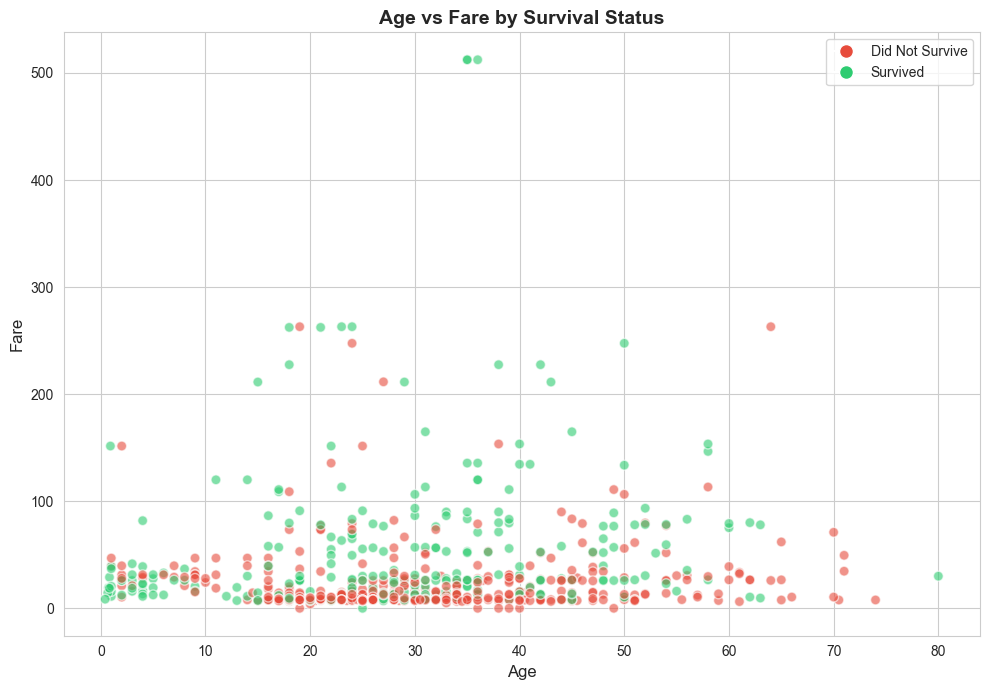


Correlation between Age and Fare: 0.096


In [5]:
# Create the scatter plot
plt.figure(figsize=(10, 7))

# Plot non-survivors and survivors with different colors
colors = df['Survived'].map({0: '#E74C3C', 1: '#2ECC71'})

# Create scatter plot
scatter = plt.scatter(df['Age'], df['Fare'], c=colors, alpha=0.6, edgecolors='white', s=50)

# Add labels and title
plt.xlabel('Age', fontsize=12)
plt.ylabel('Fare', fontsize=12)
plt.title('Age vs Fare by Survival Status', fontsize=14, fontweight='bold')

# Create custom legend
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor='#E74C3C', 
                          markersize=10, label='Did Not Survive'),
                   Line2D([0], [0], marker='o', color='w', markerfacecolor='#2ECC71', 
                          markersize=10, label='Survived')]
plt.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.savefig('visualization4_age_vs_fare.png', bbox_inches='tight', dpi=150)
plt.show()

# Calculate correlation
correlation = df[['Age', 'Fare']].dropna().corr().iloc[0, 1]
print(f"\nCorrelation between Age and Fare: {correlation:.3f}")

**Interpretation:**

The scatter plot reveals a weak positive correlation (r ≈ 0.10) between age and fare, indicating that older passengers paid slightly higher fares on average, but the relationship is not strong. More notably, the highest fares were paid by passengers of various ages, suggesting wealth was not age-dependent. Survivors (green dots) appear more frequently in the higher fare ranges, supporting the finding that wealthier passengers (who could afford expensive tickets) had better survival rates.